In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from pathlib import Path

import affinis.associations as aff
from affinis.plots import hinton

plt.rc('figure', figsize=(4.0, 3.0))
imgpath=Path('../img/')

n_cols=15
n_rows=30
B = nx.bipartite.random_graph(n_cols,n_rows, .25, seed=2)
n = list(B.nodes)[n_cols:]

X = nx.bipartite.biadjacency_matrix(B, n).toarray()

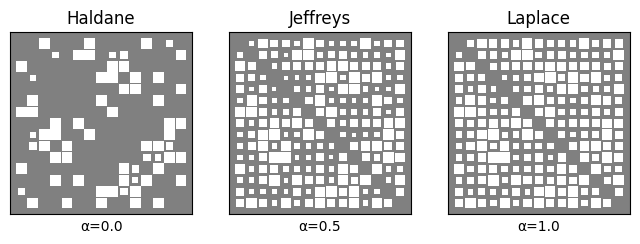

In [2]:
#| label: additive-smoothing
f,axs = plt.subplots(nrows=1, ncols=3, figsize=(8,4))
settings = {'Haldane':0., 'Jeffreys':0.5, 'Laplace':1.}

for n, (lab, a) in enumerate(settings.items()): 
    ax = axs.flatten()[n]
    fp = aff.forest_pursuit(X, pseudocts=a)
    hinton(fp, ax=ax)
    ax.set_title(lab)
    ax.set_xlabel(f'α={a:.1f}')
    
# plt.savefig(imgpath/'add-smooth.webp')

### Animation


In [3]:
psdcts = np.linspace(0,1)
psdcts = np.hstack((
    np.zeros_like(psdcts),
    psdcts,
    np.ones_like(psdcts),
    psdcts[::-1]
))

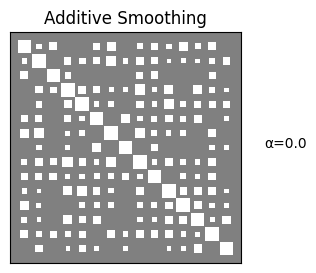

In [4]:
coo = aff.ochiai(X, pseudocts=1.)

fig, ax = plt.subplots()
scat = hinton(coo, ax=ax)
plt.title('Additive Smoothing')
annot = ax.annotate('α=0.0',(1.1,0.5), xycoords='axes fraction')

def update(frame):
    psdct = psdcts[frame]
    coo = aff.ochiai(X, pseudocts=psdct)
    newscat = hinton(coo, update_from=scat)
    annot.set_text(f'α={psdct:.1f}')
    return (newscat ,annot)

ani = animation.FuncAnimation(fig=fig, func=update, frames=psdcts.shape[0], interval=30)
ani.save(filename=imgpath/"smoothing.gif", writer="pillow")

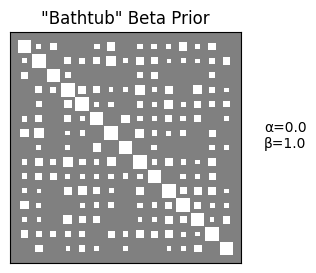

In [5]:
#| label: smoothing-zero-sum

coo = aff.ochiai(X, pseudocts=('zero-sum',1.))

fig, ax = plt.subplots()
scat = hinton(coo, ax=ax)
plt.title('"Bathtub" Beta Prior')
annot = ax.annotate('α=0.0\nβ=1.0',(1.1,0.5), xycoords='axes fraction')

def update(frame):
    psdct = ('zero-sum',psdcts[frame])
    coo = aff.ochiai(X, pseudocts=psdct)
    newscat = hinton(coo, update_from=scat)
    annot.set_text(f'α={psdct[1]:.1f}\nβ={1-psdct[1]:.1f}')
    return (newscat ,annot)

ani = animation.FuncAnimation(fig=fig, func=update, frames=psdcts.shape[0], interval=30)
ani.save(filename=imgpath/"smoothing-zero-sum.gif", writer="pillow")